In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv('car data.txt')

# First 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Տվյալների ուսումնասիրություն և նախապատրաստում
Տվյալների ընդհանուր նկարագիր

In [2]:
# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 301
Number of columns: 9


In [3]:

# սյուների տվյալների տասակները
print(df.dtypes)

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [4]:

df.describe(include='all')

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


Բացակայող արժեքներ

In [5]:
# Missing values by column
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

,0


In [6]:
# Numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 5
Categorical columns: 4


Կորելացիան վաճառքի գնի (Selling_Price) հետ՝
Selling_Price    1.000000
Present_Price    0.878983
Year             0.236141
Kms_Driven       0.029187
Owner           -0.088344
Name: Selling_Price, dtype: float64
--------------------------------------------------


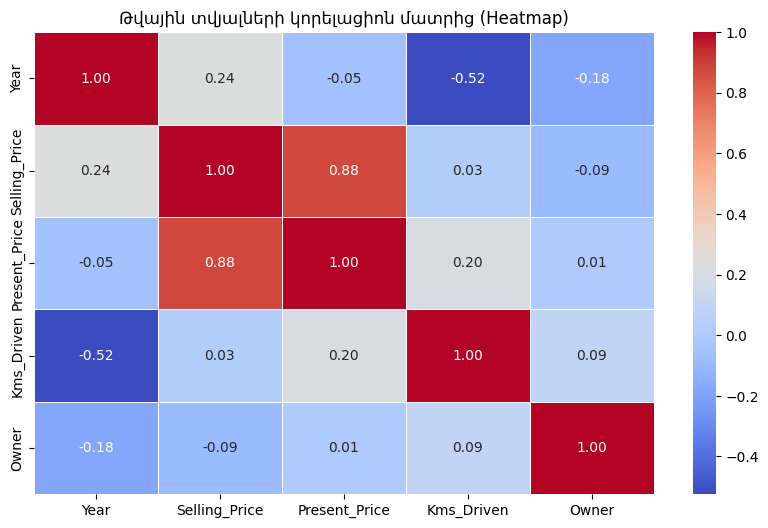

In [7]:
# 1. Գտնում ենք միայն թվային սյունակների կորելացիոն մատրիցը
corr_matrix = df.select_dtypes(include=np.number).corr()

# 2. Ֆիլտրում ենք կորելացիան հատուկ "Selling_Price"-ի հետ (նվազման կարգով)
sale_corr = corr_matrix["Selling_Price"].sort_values(ascending=False)

print("Կորելացիան վաճառքի գնի (Selling_Price) հետ՝")
print(sale_corr.head(15))
print("-" * 50)

# 3. Վիզուալիզացիա՝ Ջերմային քարտեզ (Heatmap) քո ներմուծած գրադարաններով
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Թվային տվյալների կորելացիոն մատրից (Heatmap)')
plt.show()

/tmp/ipykernel_6465/3315115829.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


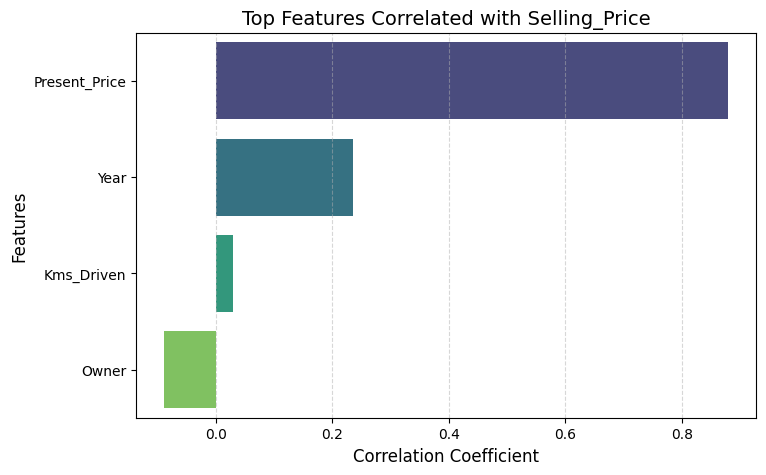

In [8]:
# 10 ամենաուժեղ կորելացիոն կապով հատկանիշները
# Քանի որ մեր թվային սյունակները քիչ են, սկվերցնի բոլոր մնացած թվային հատկանիշները
top_corr = sale_corr[1:11]

plt.figure(figsize=(8, 5))

# հորիզոնական Barplot
sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    palette="viridis"
)

plt.title("Top Features Correlated with Selling_Price", fontsize=14)
plt.xlabel("Correlation Coefficient", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Ծայրահեղ արժեքների

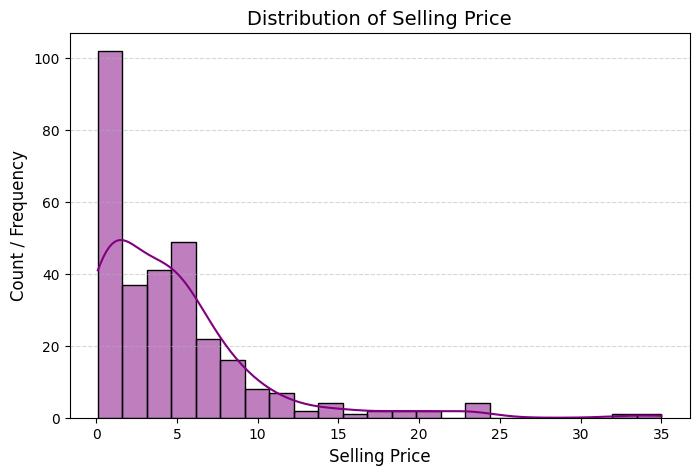

In [9]:
# Selling_Price-ի բաշխումը (Distribution)
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Selling_Price"],
    kde=True,
    color="purple"
)


plt.title("Distribution of Selling Price", fontsize=14)
plt.xlabel("Selling Price", fontsize=12)
plt.ylabel("Count / Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

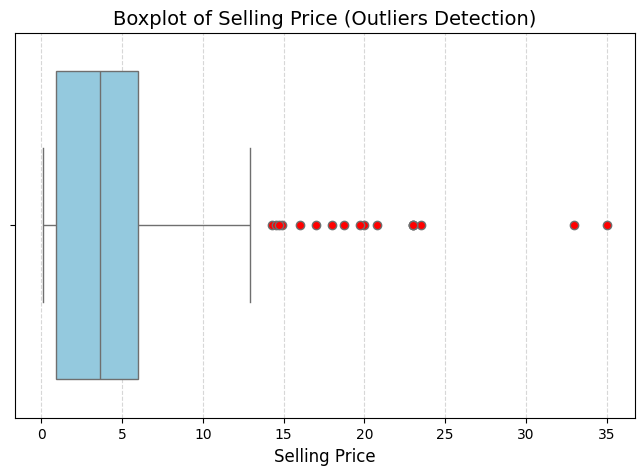

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Selling_Price"],
    color="skyblue",
    flierprops={"markerfacecolor": "red", "marker": "o"}
)

plt.title("Boxplot of Selling Price (Outliers Detection)", fontsize=14)
plt.xlabel("Selling Price", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

In [11]:
Q1 = df["Selling_Price"].quantile(0.25)
Q3 = df["Selling_Price"].quantile(0.75)
IQR = Q3 - Q1
df = df.drop(
    df[
        (df["Selling_Price"] < (Q1 - 1.5 * IQR))
        | (df["Selling_Price"] > (Q3 + 1.5 * IQR))
    ].index
)

In [12]:
print(df.shape)

(284, 9)


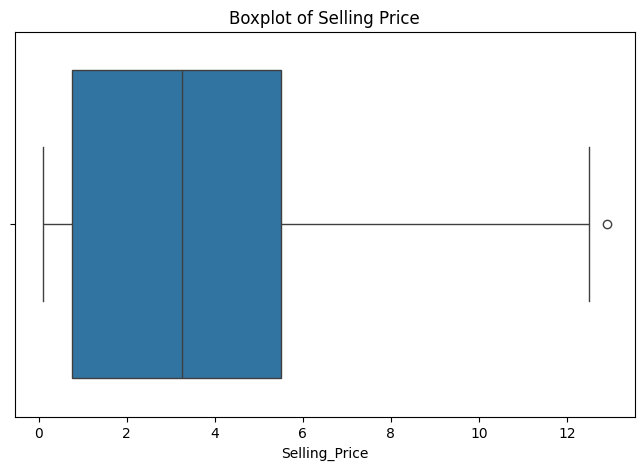

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Selling_Price"])

plt.title("Boxplot of Selling Price")
plt.show()

Feature engineering

In [14]:
df["Car_Age"] = 2026 - df["Year"]

df["Price_Depreciation_Ratio"] = (df["Present_Price"] - df["Selling_Price"]) / df[
    "Present_Price"
]

df[["Car_Age", "Price_Depreciation_Ratio"]].head()

,Car_Age,Price_Depreciation_Ratio
0,12,0.400716
1,13,0.502096
2,9,0.263959
3,15,0.313253
4,12,0.330422


In [15]:
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of categorical columns: 4
Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')


In [16]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.shape)
df.head()

(284, 107)


,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Price_Depreciation_Ratio,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,Car_Name_Bajaj Avenger 220,Car_Name_Bajaj Avenger 220 dtsi,Car_Name_Bajaj Avenger Street 220,Car_Name_Bajaj Discover 100,Car_Name_Bajaj Discover 125,Car_Name_Bajaj Dominar 400,Car_Name_Bajaj Pulsar NS 200,Car_Name_Bajaj Pulsar 135 LS,Car_Name_Bajaj Pulsar 150,Car_Name_Bajaj Pulsar 220 F,Car_Name_Bajaj Pulsar NS 200,Car_Name_Bajaj Pulsar RS200,Car_Name_Hero CBZ Xtreme,Car_Name_Hero Ignitor Disc,Car_Name_Hero Extreme,Car_Name_Hero Glamour,Car_Name_Hero Honda CBZ extreme,Car_Name_Hero Honda Passion Pro,Car_Name_Hero Hunk,Car_Name_Hero Passion Pro,Car_Name_Hero Passion X pro,Car_Name_Hero Splender Plus,Car_Name_Hero Splender iSmart,Car_Name_Hero Super Splendor,Car_Name_Honda Activa 125,Car_Name_Honda Activa 4G,Car_Name_Honda CB Hornet 160R,Car_Name_Honda CB Shine,Car_Name_Honda CB Trigger,Car_Name_Honda CB Unicorn,Car_Name_Honda CB twister,Car_Name_Honda CBR 150,Car_Name_Honda Dream Yuga,Car_Name_Honda Karizma,Car_Name_Hyosung GT250R,Car_Name_KTM 390 Duke,Car_Name_KTM RC200,Car_Name_KTM RC390,Car_Name_Mahindra Mojo XT300,Car_Name_Royal Enfield Bullet 350,Car_Name_Royal Enfield Classic 350,Car_Name_Royal Enfield Classic 500,Car_Name_Royal Enfield Thunder 350,Car_Name_Royal Enfield Thunder 500,Car_Name_Suzuki Access 125,Car_Name_TVS Apache RTR 160,Car_Name_TVS Apache RTR 180,Car_Name_TVS Jupyter,Car_Name_TVS Sport,Car_Name_TVS Wego,Car_Name_UM Renegade Mojave,Car_Name_Yamaha FZ v 2.0,Car_Name_Yamaha FZ 16,Car_Name_Yamaha FZ S,Car_Name_Yamaha FZ S V 2.0,Car_Name_Yamaha Fazer,Car_Name_alto 800,Car_Name_alto k10,Car_Name_amaze,Car_Name_baleno,Car_Name_brio,Car_Name_camry,Car_Name_ciaz,Car_Name_city,Car_Name_corolla,Car_Name_corolla altis,Car_Name_creta,Car_Name_dzire,Car_Name_elantra,Car_Name_eon,Car_Name_ertiga,Car_Name_etios cross,Car_Name_etios g,Car_Name_etios gd,Car_Name_etios liva,Car_Name_fortuner,Car_Name_grand i10,Car_Name_i10,Car_Name_i20,Car_Name_ignis,Car_Name_innova,Car_Name_jazz,Car_Name_omni,Car_Name_ritz,Car_Name_s cross,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,12,0.400716,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True
1,2013,4.75,9.54,43000,0,13,0.502096,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True
2,2017,7.25,9.85,6900,0,9,0.263959,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

Մոդելի ուսուցում

In [17]:
y = df["Selling_Price"]

X = df.drop(["Selling_Price", "Car_Name"], axis=1, errors="ignore")

print(X.shape)
print(y.shape)

(284, 106)
(284,)


In [18]:

# տվյալների բաժանում
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (227, 106)
Test shape: (57, 106)


In [20]:
# Ստեղծում ենք StandardScaler-ի օբյեկտը
scaler = StandardScaler()

# Մարզող (train) տվյալների հիման վրա հաշվում ենք միջինն ու ստանդարտ շեղումը և նորմավորում դրանք
X_train_scaled = scaler.fit_transform(X_train)

# Թեստային (test) տվյալները նորմավորում ենք միայն մարզող տվյալներից ստացված պարամետրերով
X_test_scaled = scaler.transform(X_test)

# Տպում ենք նորմավորված տվյալների չափերը (տողեր, սյուներ)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(227, 106)
(57, 106)


Linear Regression

Linear Regression MAE: 0.718379743035276
Linear Regression MSE: 1.2280374725602057
Linear Regression RMSE: 1.1081685217331367


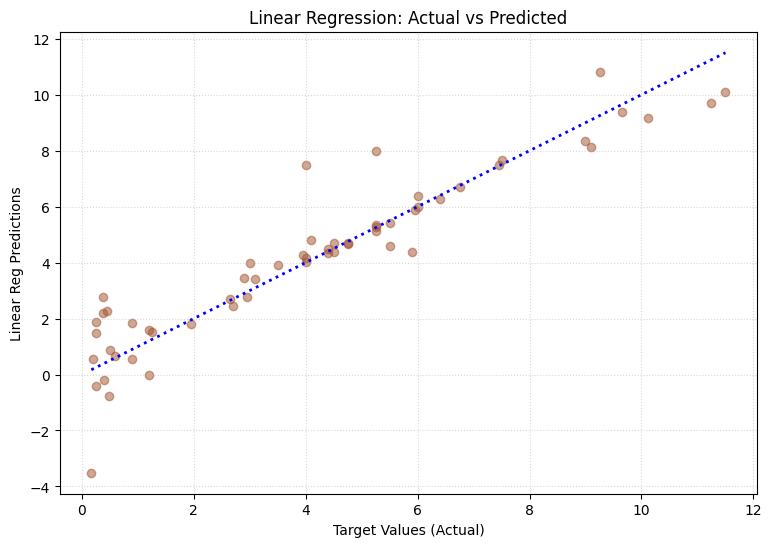

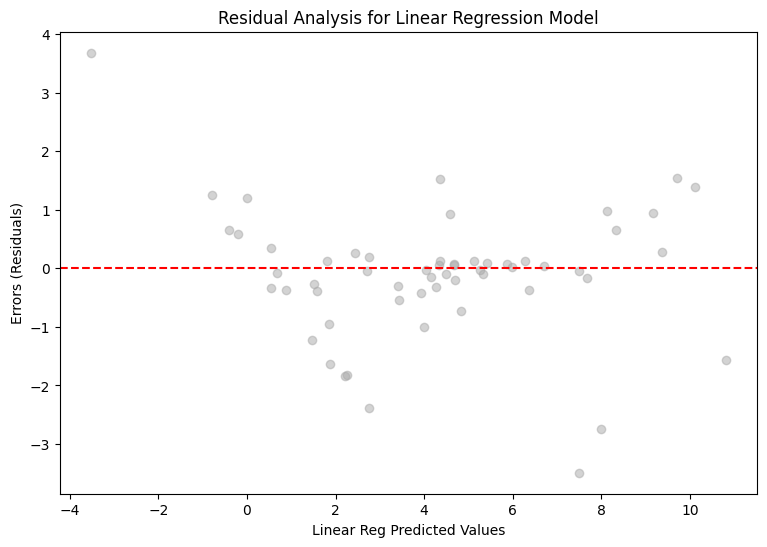

In [87]:
from sklearn.linear_model import LinearRegression

# Մոդելի սահմանում և ուսուցանում
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# Կանխատեսումների ստացում
predictions_lr = linear_reg.predict(X_test)

# Մետրիկաների հաշվարկ և տպում
mae_score_lr = mean_absolute_error(y_test, predictions_lr)
mse_score_lr = mean_squared_error(y_test, predictions_lr)
rmse_score_lr = np.sqrt(mse_score_lr)

print(f"Linear Regression MAE: {mae_score_lr}")
print(f"Linear Regression MSE: {mse_score_lr}")
print(f"Linear Regression RMSE: {rmse_score_lr}")

# Սխալների (մնացորդների) հաշվարկ
errors_lr = y_test - predictions_lr

# Գրաֆիկ 1․ Իրական և կանխատեսված արժեքների համեմատություն
plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions_lr, alpha=0.5, color='sienna')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue', linestyle=':', linewidth=2)
plt.xlabel("Target Values (Actual)")
plt.ylabel("Linear Reg Predictions")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Գրաֆիկ 2․ Մնացորդների (Residuals) անալիզ
plt.figure(figsize=(9, 6))
plt.scatter(predictions_lr, errors_lr, alpha=0.5, color='darkgrey')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Linear Reg Predicted Values")
plt.ylabel("Errors (Residuals)")
plt.title("Residual Analysis for Linear Regression Model")
plt.show()

In [23]:
# Ստեղծում ենք նոր DataFrame, որտեղ կպահվեն հատկանիշների անունները և դրանց համապատասխան գործակիցները
coef_df = pd.DataFrame({
    "Feature": X.columns,          # Հատկանիշների (սյունակների) անունները X-ից
    "Coefficient": lr_model.coef_  # Մոդելի կողմից հաշվարկված գործակիցները (կշիռները)
})

# Ցուցադրում ենք ստացված աղյուսակը
coef_df

,Feature,Coefficient
0,Year,0.103112
1,Present_Price,2.600471
2,Kms_Driven,-0.012582
3,Owner,-0.009584
4,Car_Age,-0.103112
...,...,...
101,Car_Name_xcent,-0.158115
102,Fuel_Type_Diesel,0.248472
103,Fuel_Type_Petrol,0.123047
104,Seller_Type_Individual,-0.065449


In [24]:
# Հաշվում ենք յուրաքանչյուր գործակցի բացարձակ արժեքը (մոդուլը) և պահում "AbsCoef" սյունակում
coef_df["AbsCoef"] = abs(coef_df["Coefficient"])

# Սորտավորում ենք աղյուսակը ըստ բացարձակ արժեքի՝ նվազման կարգով, և ցուցադրում առաջին 15-ը
# Սա ցույց է տալիս, թե որ հատկանիշներն ունեն ամենամեծ ազդեցությունը մոդելի կանխատեսման վրա
coef_df.sort_values(
    by="AbsCoef",
    ascending=False
).head(15)

,Feature,Coefficient,AbsCoef
1,Present_Price,2.600471,2.600471
5,Price_Depreciation_Ratio,-1.268919,1.268919
76,Car_Name_corolla altis,-0.877557,0.877557
72,Car_Name_camry,-0.604984,0.604984
51,Car_Name_Royal Enfield Classic 350,-0.565551,0.565551
74,Car_Name_city,-0.547101,0.547101
71,Car_Name_brio,-0.494423,0.494423
98,Car_Name_verna,-0.474299,0.474299
36,Car_Name_Honda Activa 4G,-0.469055,0.469055
37,Car_Name_Honda CB Hornet 160R,-0.468258,0.468258


In [25]:
# Օգտագործելով նորմավորված թեստային տվյալները՝ կատարում ենք գնի կանխատեսում
y_pred_lr = lr_model.predict(X_test_scaled)

# Ստեղծում ենք DataFrame, որտեղ կողք կողքի կերևան իրական և մոդելի կանխատեսած գները
results = pd.DataFrame({
    "Actual": y_test,          # Իրական արժեքները թեստային բազայից
    "Predicted": y_pred_lr     # Գծային ռեգրեսիայի կանխատեսած արժեքները
})

# Ցուցադրում ենք առաջին 10 տողը՝ արդյունքները տեսողականորեն համեմատելու համար
results.head(10)

,Actual,Predicted
9,7.45,7.489320
270,4.10,4.823697
174,0.38,2.758813
226,5.25,5.127831
89,4.75,4.678201
249,5.25,5.273655
280,5.25,5.339874
187,0.25,1.474782
42,1.95,1.818423
242,4.40,4.345732


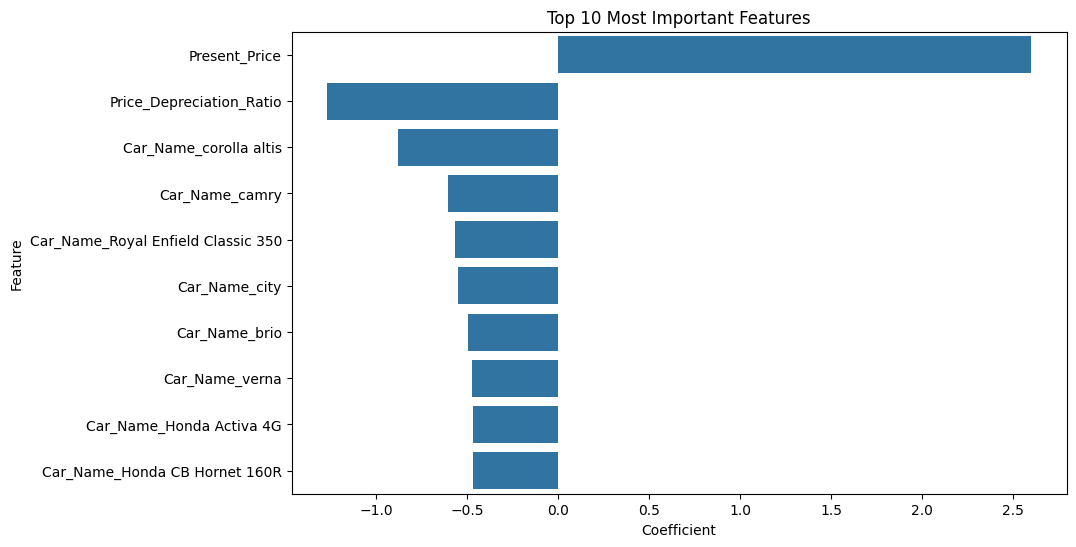

In [31]:
# 10 ամենաազդեցիկ հատկանիշներն ըստ բացարձակ գործակցի արժեքի
top_features = coef_df.sort_values(
    by="AbsCoef",
    ascending=False
).head(10)


plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.show()

In [32]:
# Տպում ենք վերնագիրը և բաժանարար գիծը՝ արդյունքները գեղեցիկ տեսքով ցուցադրելու համար
print("Linear Regression Results")
print("-" * 30)

# Տպում ենք Միջին Բացարձակ Սխալանքը (MAE)
print("MAE :", mae_lr)

# Տպում ենք Միջին Քառակուսային Սխալանքը (MSE)
print("MSE :", mse_lr)

# Տպում ենք Արմատային Միջին Քառակուսային Սխալանքը (RMSE)
print("RMSE:", rmse_lr)

Linear Regression Results
------------------------------
MAE : 0.7183797430367308
MSE : 1.228037472574381
RMSE: 1.1081685217395327


Lasso Regression

Lasso Regression MAE: 1.1609800550287095
Lasso Regression MSE: 3.2736655116009925
Lasso Regression RMSE: 1.8093273644094903


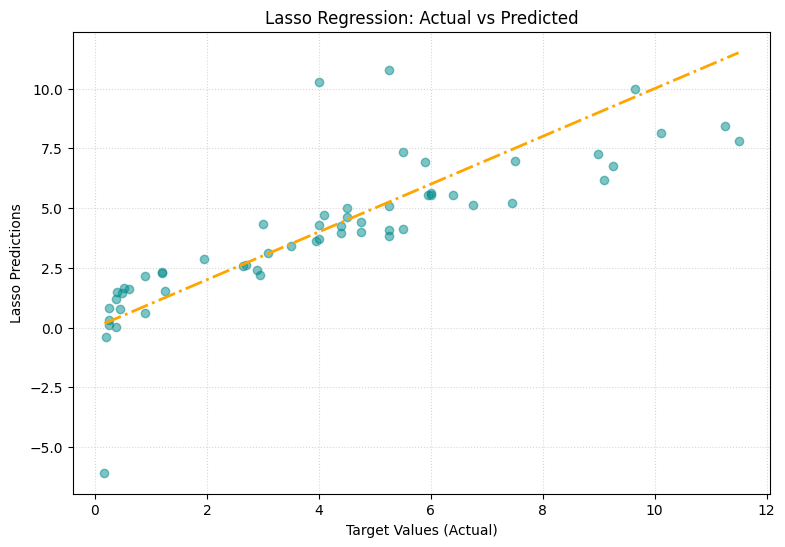

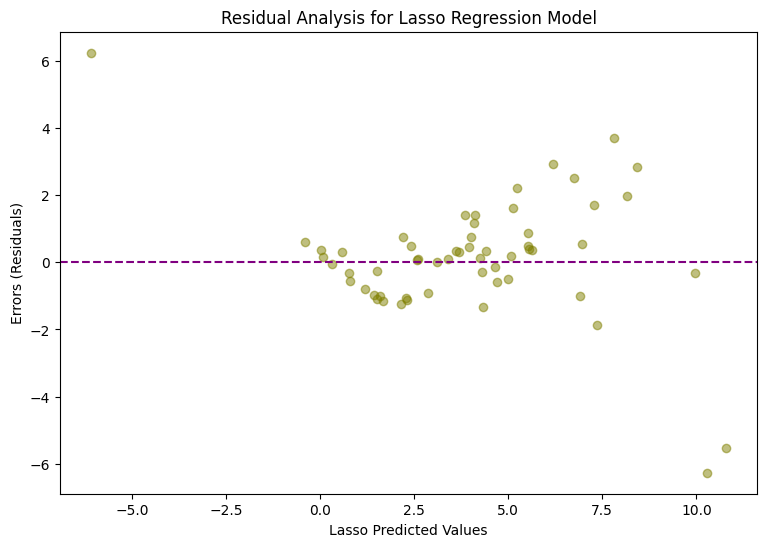

In [86]:
from sklearn.linear_model import Lasso

# Մոդելի սահմանում և ուսուցանում
lasso_reg = Lasso(alpha=1.0, random_state=42)
lasso_reg.fit(X_train, y_train)

# Կանխատեսումների ստացում
predictions_lasso = lasso_reg.predict(X_test)

# Մետրիկաների հաշվարկ և տպում
mae_score_lasso = mean_absolute_error(y_test, predictions_lasso)
mse_score_lasso = mean_squared_error(y_test, predictions_lasso)
rmse_score_lasso = np.sqrt(mse_score_lasso)

print(f"Lasso Regression MAE: {mae_score_lasso}")
print(f"Lasso Regression MSE: {mse_score_lasso}")
print(f"Lasso Regression RMSE: {rmse_score_lasso}")

# Սխալների (մնացորդների) հաշվարկ
errors_lasso = y_test - predictions_lasso

# Գրաֆիկ 1․ Իրական և կանխատեսված արժեքների համեմատություն
plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions_lasso, alpha=0.5, color='darkcyan')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', linestyle='-.', linewidth=2)
plt.xlabel("Target Values (Actual)")
plt.ylabel("Lasso Predictions")
plt.title("Lasso Regression: Actual vs Predicted")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Գրաֆիկ 2․ Մնացորդների (Residuals) անալիզ
plt.figure(figsize=(9, 6))
plt.scatter(predictions_lasso, errors_lasso, alpha=0.5, color='olive')
plt.axhline(y=0, color='purple', linestyle='--')
plt.xlabel("Lasso Predicted Values")
plt.ylabel("Errors (Residuals)")
plt.title("Residual Analysis for Lasso Regression Model")
plt.show()

KNN

In [36]:
# Սահմանում ենք k-ի արժեքների միջակայքը 1-ից մինչև 49 (50-ը ներառված չէ)
k_values = range(1, 50)

# Ստեղծում ենք դատարկ ցուցակ, որտեղ կպահենք յուրաքանչյուր k-ի համար հաշվարկված RMSE արժեքները
rmse_values = []

# Անցնում ենք 1-ից 49 բոլոր k-երի վրայով
for k in k_values:

    # Սահմանում ենք KNN ռեգրեսիայի մոդելը՝ ընթացիկ k հարևանների քանակով
    model = KNeighborsRegressor(
        n_neighbors=k
    )

    # Մարզում ենք մոդելը նորմավորված տվյալների վրա
    model.fit(
        X_train_scaled,
        y_train
    )

    # Կատարում ենք կանխատեսում թեստային տվյալների համար
    pred = model.predict(
        X_test_scaled
    )

    # Հաշվում ենք Արմատային Միջին Քառակուսային Սխալանքը (RMSE) ընթացիկ k-ի համար
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    # Ավելացնում ենք ստացված RMSE արժեքը մեր ցուցակի մեջ
    rmse_values.append(rmse)

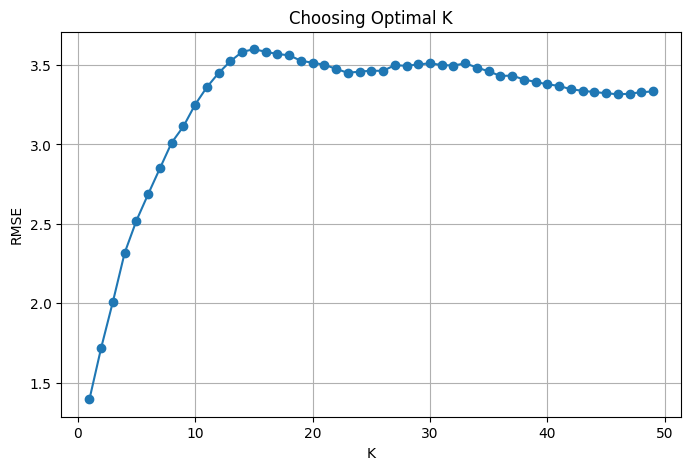

In [37]:
# Սահմանում ենք գրաֆիկի պատուհանի չափսերը (լայնություն=8, բարձրություն=5)
plt.figure(figsize=(8, 5))

# Գծում ենք k-ի արժեքների և համապատասխան RMSE-ների կապը ցույց տվող գիծը
# marker='o' պարամետրը գծի վրա կետերով նշում է յուրաքանչյուր k-ի կոնկրետ արժեքը
plt.plot(
    k_values,
    rmse_values,
    marker='o'
)

# Ավելացնում ենք առանցքների անվանումները
# x առանցքի վրա հարևանների քանակն է (K), իսկ y-ի վրա՝ սխալանքը (RMSE)
plt.xlabel("K")
plt.ylabel("RMSE")

# Ավելացնում ենք գրաֆիկի վերնագիրը
plt.title("Choosing Optimal K")

# Ավելացնում ենք ցանց (grid), որպեսզի գրաֆիկի վրայից օպտիմալ k-ի արժեքը գտնելն ավելի հեշտ լինի
plt.grid()

# Ցուցադրում ենք պատրաստի գրաֆիկը
plt.show()

In [38]:
# np.argmin(rmse_values)-ը գտնում է rmse_values ցուցակի ամենափոքր արժեքի ինդեքսը (դիրքը)
# Այդ ինդեքսով k_values-ից վերցնում ենք համապատասխան լավագույն k-ի արժեքը
best_k = k_values[np.argmin(rmse_values)]

# Տպում ենք գտնված լավագույն (օպտիմալ) K-ի արժեքը
print("Best K =", best_k)

Best K = 1


STANDARD KNN REGRESSION (Ստանդարտ KNN Ռեգրեսիա)

Standard KNN MAE: 2.824912280701754
Standard KNN MSE: 12.886628631578947
Standard KNN RMSE: 3.589795068186894


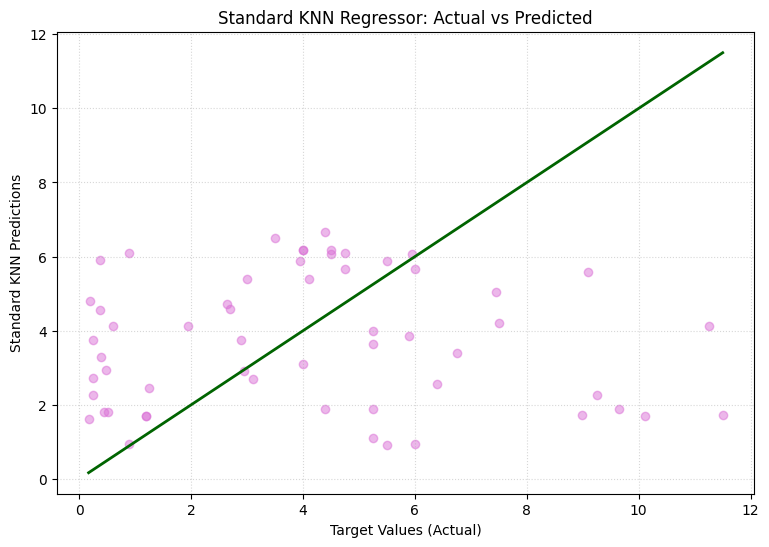

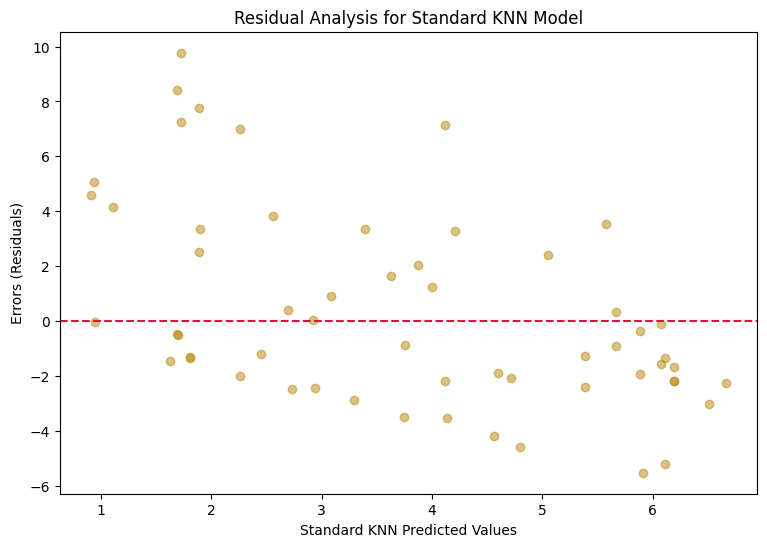

In [85]:
# Մոդելի սահմանում և ուսուցանում (սովորական հավասար կշիռներով)
standard_knn_reg = KNeighborsRegressor(n_neighbors=5, weights='uniform')
standard_knn_reg.fit(X_train, y_train)

# Կանխատեսումների ստացում
predictions_knn = standard_knn_reg.predict(X_test)

# Մետրիկաների հաշվարկ և տպում
mae_score_knn = mean_absolute_error(y_test, predictions_knn)
mse_score_knn = mean_squared_error(y_test, predictions_knn)
rmse_score_knn = np.sqrt(mse_score_knn)

print(f"Standard KNN MAE: {mae_score_knn}")
print(f"Standard KNN MSE: {mse_score_knn}")
print(f"Standard KNN RMSE: {rmse_score_knn}")

# Սխալների (մնացորդների) հաշվարկ
errors_knn = y_test - predictions_knn

# Գրաֆիկ 1․ Իրական և կանխատեսված արժեքների համեմատություն
plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions_knn, alpha=0.5, color='orchid')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='darkgreen', linestyle='-', linewidth=2)
plt.xlabel("Target Values (Actual)")
plt.ylabel("Standard KNN Predictions")
plt.title("Standard KNN Regressor: Actual vs Predicted")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Գրաֆիկ 2․ Մնացորդների (Residuals) անալիզ
plt.figure(figsize=(9, 6))
plt.scatter(predictions_knn, errors_knn, alpha=0.5, color='darkgoldenrod')
plt.axhline(y=0, color='crimson', linestyle='--')
plt.xlabel("Standard KNN Predicted Values")
plt.ylabel("Errors (Residuals)")
plt.title("Residual Analysis for Standard KNN Model")
plt.show()

WEIGHTED KNN REGRESSION (Կշռված KNN Ռեգրեսիա)

Weighted KNN MAE: 2.6396128707175963
Weighted KNN MSE: 13.316227919479516
Weighted KNN RMSE: 3.6491407097396937


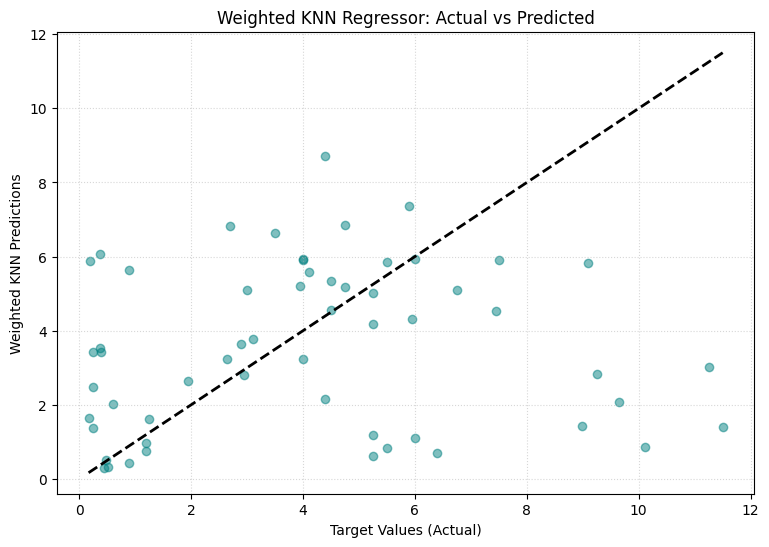

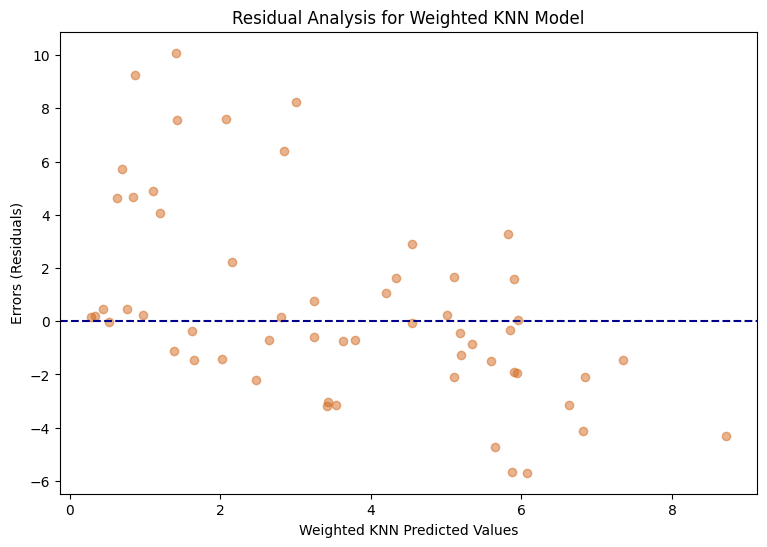

In [84]:
from sklearn.neighbors import KNeighborsRegressor

# Մոդելի սահմանում և ուսուցանում (կշիռները՝ ըստ հեռավորության)
weighted_knn_reg = KNeighborsRegressor(n_neighbors=5, weights='distance')
weighted_knn_reg.fit(X_train, y_train)

# Կանխատեսումների ստացում
predictions_weighted = weighted_knn_reg.predict(X_test)

# Մետրիկաների հաշվարկ և տպում
mae_score_weighted = mean_absolute_error(y_test, predictions_weighted)
mse_score_weighted = mean_squared_error(y_test, predictions_weighted)
rmse_score_weighted = np.sqrt(mse_score_weighted)

print(f"Weighted KNN MAE: {mae_score_weighted}")
print(f"Weighted KNN MSE: {mse_score_weighted}")
print(f"Weighted KNN RMSE: {rmse_score_weighted}")

# Սխալների (մնացորդների) հաշվարկ
errors_weighted = y_test - predictions_weighted

# Գրաֆիկ 1․ Իրական և կանխատեսված արժեքների համեմատություն
plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions_weighted, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--', linewidth=2)
plt.xlabel("Target Values (Actual)")
plt.ylabel("Weighted KNN Predictions")
plt.title("Weighted KNN Regressor: Actual vs Predicted")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Գրաֆիկ 2․ Մնացորդների (Residuals) անալիզ
plt.figure(figsize=(9, 6))
plt.scatter(predictions_weighted, errors_weighted, alpha=0.5, color='chocolate')
plt.axhline(y=0, color='darkblue', linestyle='--')
plt.xlabel("Weighted KNN Predicted Values")
plt.ylabel("Errors (Residuals)")
plt.title("Residual Analysis for Weighted KNN Model")
plt.show()

Որոշման ծառեր

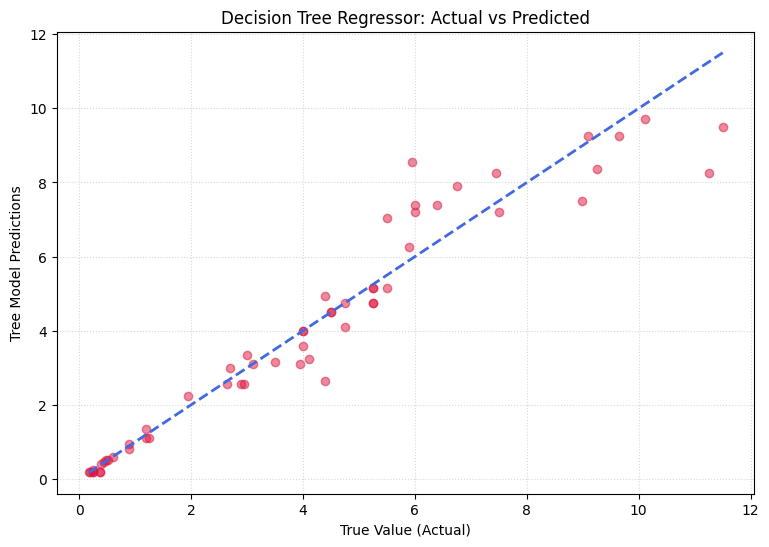

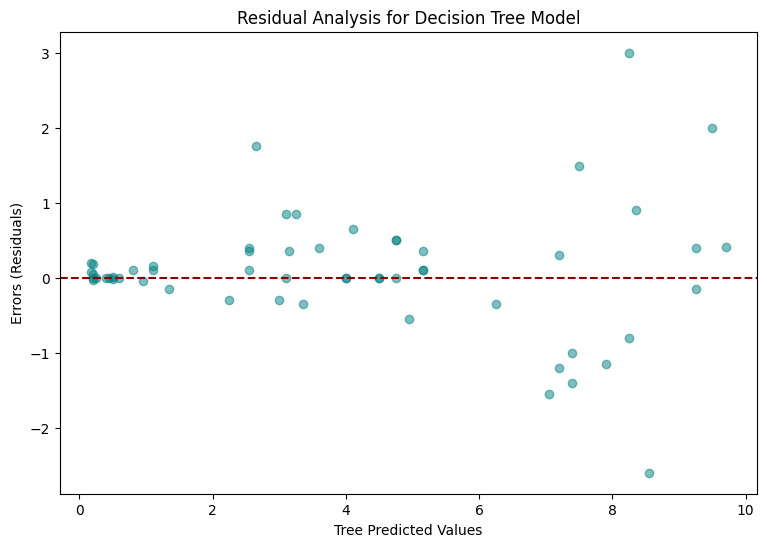

/tmp/ipykernel_6465/608172865.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=significant_features_tree, x="Importance_Score", y="Feature_Name", palette="rocket")


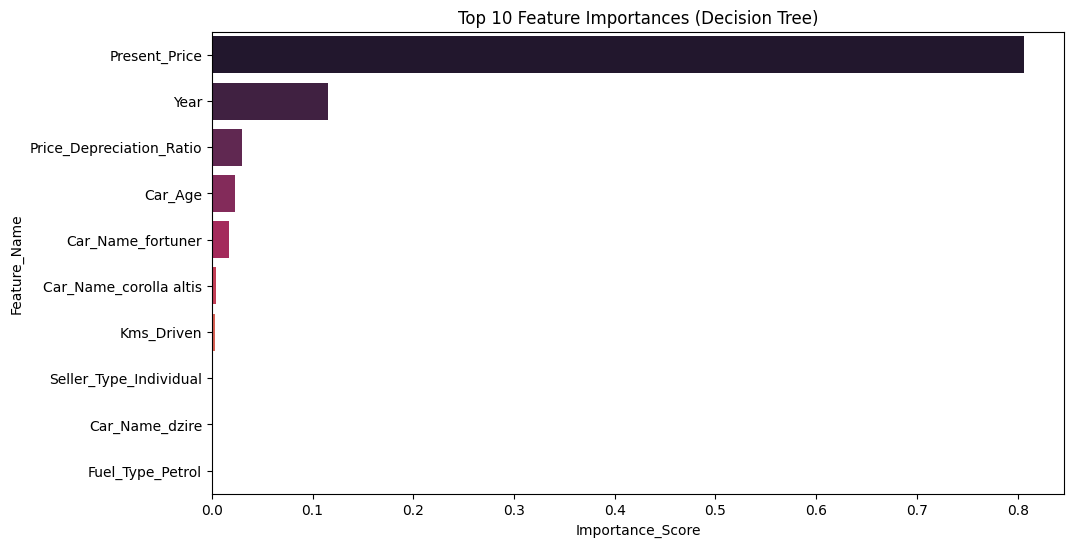

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Մոդելի սահմանում և ուսուցանում
d_tree_reg = DecisionTreeRegressor(random_state=42)
d_tree_reg.fit(X_train, y_train)

# Կանխատեսումների ստացում
predictions_tree = d_tree_reg.predict(X_test)

# Սխալների (մնացորդների) հաշվարկ
errors_tree = y_test - predictions_tree

# Գրաֆիկ 1․ Իրական և կանխատեսված արժեքների համեմատություն
plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions_tree, alpha=0.5, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='royalblue', linestyle='--', linewidth=2)
plt.xlabel("True Value (Actual)")
plt.ylabel("Tree Model Predictions")
plt.title("Decision Tree Regressor: Actual vs Predicted")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Գրաֆիկ 2․ Մնացորդների (Residuals) անալիզ
plt.figure(figsize=(9, 6))
plt.scatter(predictions_tree, errors_tree, alpha=0.5, color='teal')
plt.axhline(y=0, color='darkred', linestyle='--')
plt.xlabel("Tree Predicted Values")
plt.ylabel("Errors (Residuals)")
plt.title("Residual Analysis for Decision Tree Model")
plt.show()

# Հատկանիշների կարևորության աղյուսակ և գրաֆիկ
feat_importance_df = pd.DataFrame({
    "Feature_Name": X.columns,
    "Importance_Score": d_tree_reg.feature_importances_
})
significant_features_tree = feat_importance_df.sort_values(by="Importance_Score", ascending=False).head(10)

plt.figure(figsize=(11, 6))
sns.barplot(data=significant_features_tree, x="Importance_Score", y="Feature_Name", palette="rocket")
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.show()

Random Forest

Random Forest MAE: 0.34500730994152057
Random Forest MSE: 0.3910078246832358
Random Forest RMSE: 0.625306184747309


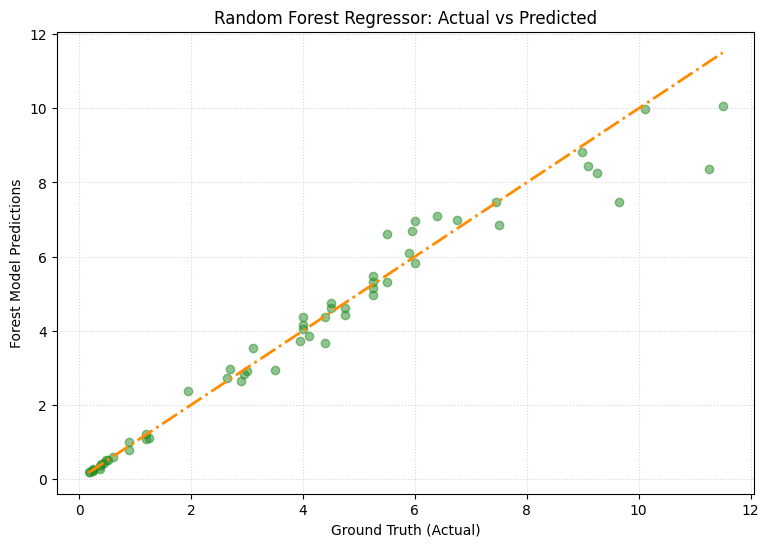

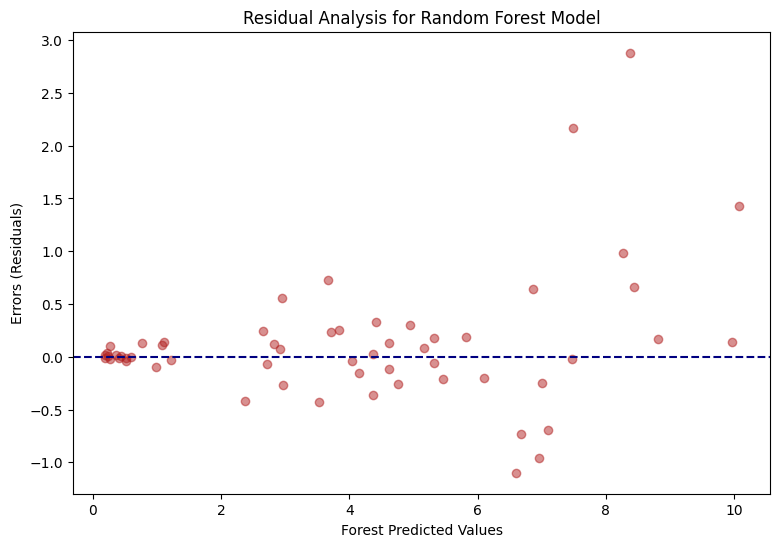

In [80]:
# Մոդելի սահմանում և ուսուցանում
random_forest_reg = RandomForestRegressor(n_estimators=120, random_state=100)
random_forest_reg.fit(X_train, y_train)

# Կանխատեսումների ստացում
predictions_rf = random_forest_reg.predict(X_test)

# Մետրիկաների հաշվարկ և տպում
mae_score_rf = mean_absolute_error(y_test, predictions_rf)
mse_score_rf = mean_squared_error(y_test, predictions_rf)
rmse_score_rf = np.sqrt(mse_score_rf)

print(f"Random Forest MAE: {mae_score_rf}")
print(f"Random Forest MSE: {mse_score_rf}")
print(f"Random Forest RMSE: {rmse_score_rf}")

# Սխալների (մնացորդների) հաշվարկ
errors_rf = y_test - predictions_rf

# Գրաֆիկ 1․ Իրական և կանխատեսված արժեքների համեմատություն
plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions_rf, alpha=0.5, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='darkorange', linestyle='-.', linewidth=2)
plt.xlabel("Ground Truth (Actual)")
plt.ylabel("Forest Model Predictions")
plt.title("Random Forest Regressor: Actual vs Predicted")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Գրաֆիկ 2․ Մնացորդների (Residuals) անալիզ
plt.figure(figsize=(9, 6))
plt.scatter(predictions_rf, errors_rf, alpha=0.5, color='firebrick')
plt.axhline(y=0, color='navy', linestyle='--')
plt.xlabel("Forest Predicted Values")
plt.ylabel("Errors (Residuals)")
plt.title("Residual Analysis for Random Forest Model")
plt.show()

# Հատկանիշների կարևորության առանձնացում
rf_feat_importance_df = pd.DataFrame({
    "Feature_Name": X.columns,
    "Importance_Value": random_forest_reg.feature_importances_
})
significant_features_rf = rf_feat_importance_df.sort_values(by="Importance_Value", ascending=False).head(10)

Boosting

Gradient Boosting MAE: 0.2944884434811424
Gradient Boosting MSE: 0.24832308264171352
Gradient Boosting RMSE: 0.4983202611190052


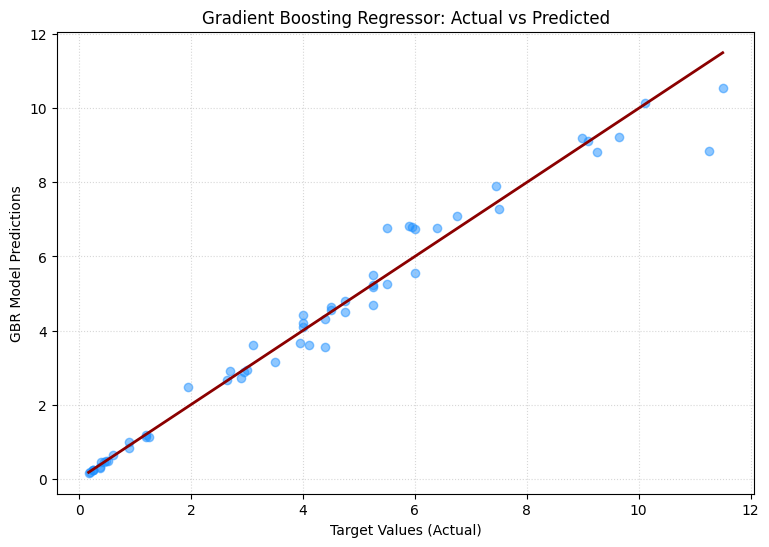

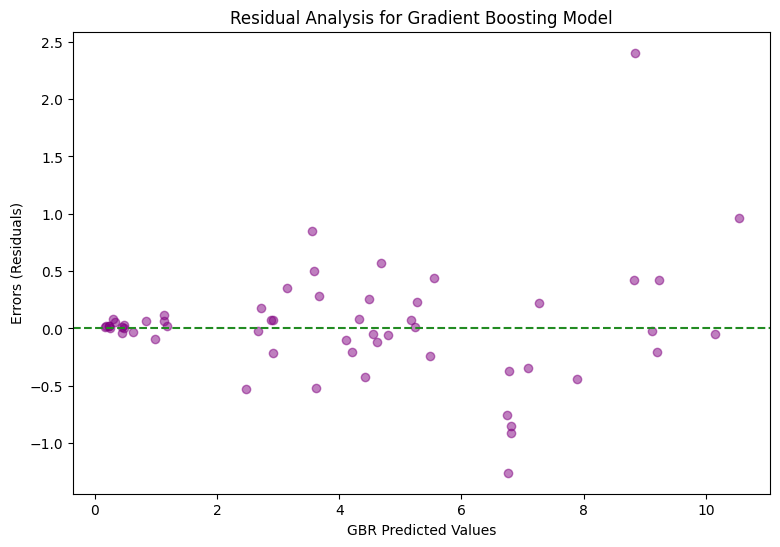

In [81]:
# Մոդելի սահմանում և ուսուցանում
grad_boosting_reg = GradientBoostingRegressor(n_estimators=120, learning_rate=0.08, max_depth=4, random_state=100)
grad_boosting_reg.fit(X_train, y_train)

# Կանխատեսումների ստացում
predictions_gbr = grad_boosting_reg.predict(X_test)

# Մետրիկաների հաշվարկ և տպում
mae_score_gbr = mean_absolute_error(y_test, predictions_gbr)
mse_score_gbr = mean_squared_error(y_test, predictions_gbr)
rmse_score_gbr = np.sqrt(mse_score_gbr)

print(f"Gradient Boosting MAE: {mae_score_gbr}")
print(f"Gradient Boosting MSE: {mse_score_gbr}")
print(f"Gradient Boosting RMSE: {rmse_score_gbr}")

# Սխալների (մնացորդների) հաշվարկ
errors_gbr = y_test - predictions_gbr

# Գրաֆիկ 1․ Իրական և կանխատեսված արժեքների համեմատություն
plt.figure(figsize=(9, 6))
plt.scatter(y_test, predictions_gbr, alpha=0.5, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='darkred', linestyle='-', linewidth=2)
plt.xlabel("Target Values (Actual)")
plt.ylabel("GBR Model Predictions")
plt.title("Gradient Boosting Regressor: Actual vs Predicted")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Գրաֆիկ 2․ Մնացորդների (Residuals) անալիզ
plt.figure(figsize=(9, 6))
plt.scatter(predictions_gbr, errors_gbr, alpha=0.5, color='purple')
plt.axhline(y=0, color='forestgreen', linestyle='--')
plt.xlabel("GBR Predicted Values")
plt.ylabel("Errors (Residuals)")
plt.title("Residual Analysis for Gradient Boosting Model")
plt.show()

# Հատկանիշների կարևորության առանձնացում
gbr_feat_importance_df = pd.DataFrame({
    "Feature_Name": X.columns,
    "Importance_Value": grad_boosting_reg.feature_importances_
})
significant_features_gbr = gbr_feat_importance_df.sort_values(by="Importance_Value", ascending=False).head(10)

Մոդելների համեմատություն

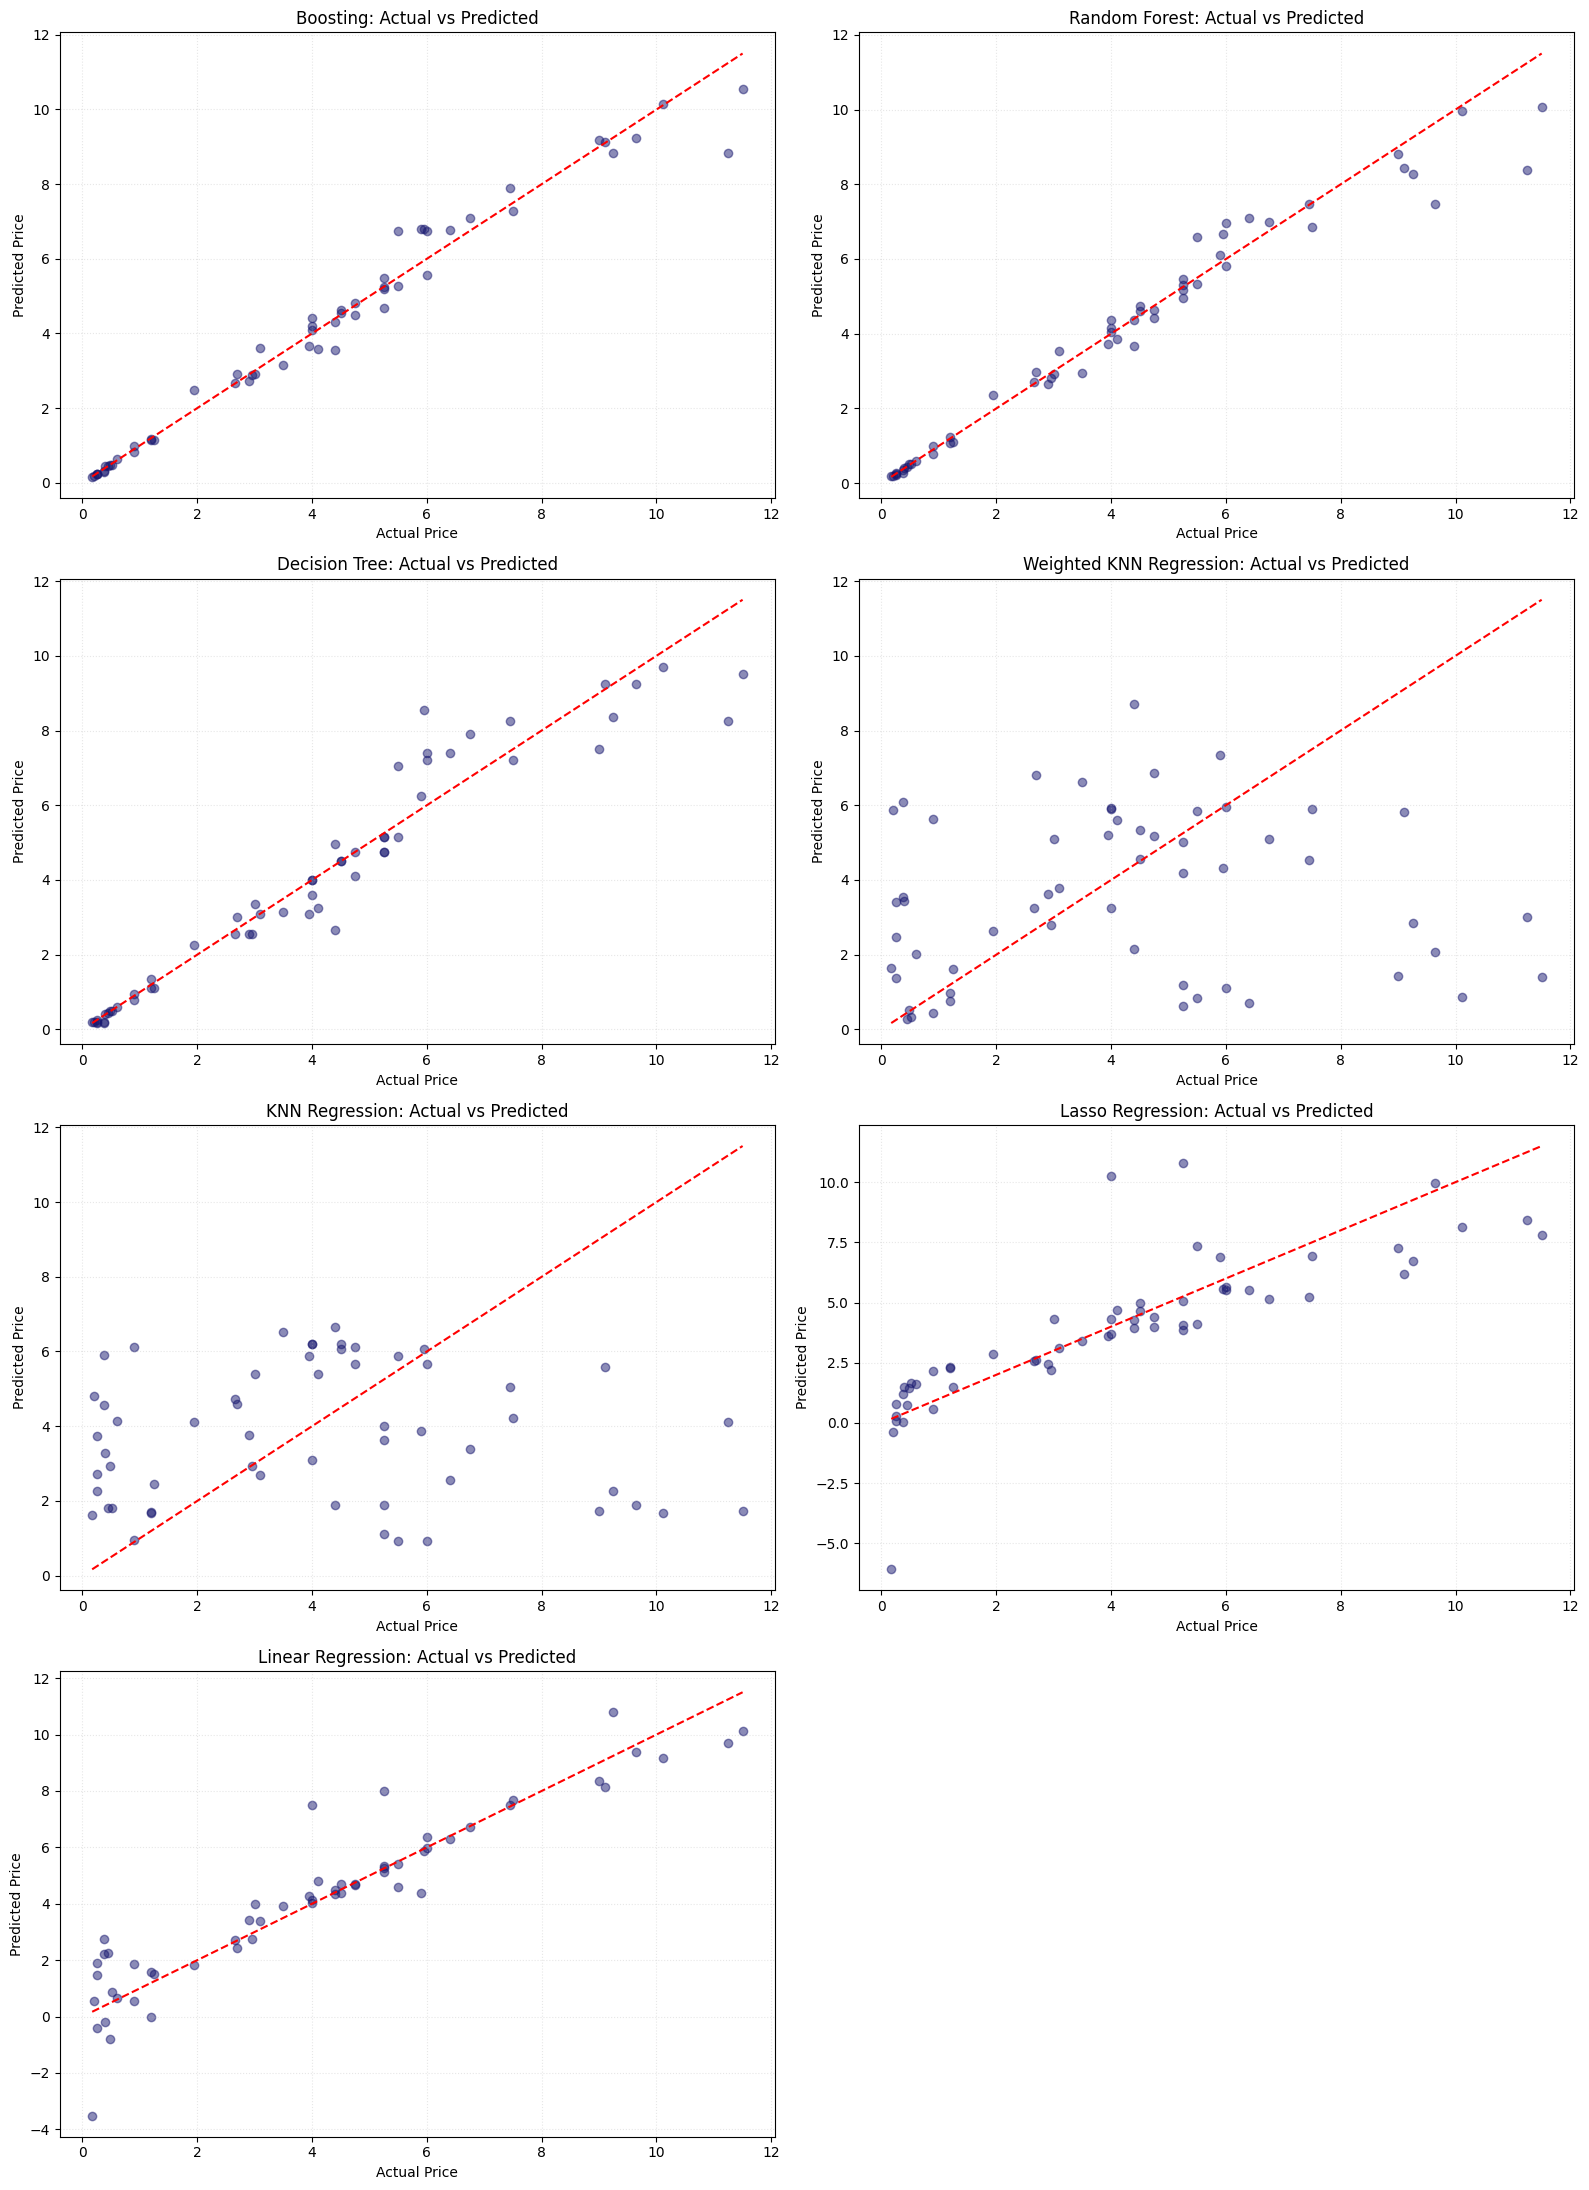

In [88]:
import matplotlib.pyplot as plt

# 1. Բոլոր 7 մոդելների անվանումների և համապատասխան նոր փոփոխականների ցուցակի սահմանում
models = [
    ("Boosting", predictions_gbr),
    ("Random Forest", predictions_rf),
    ("Decision Tree", predictions_tree),
    ("Weighted KNN Regression", predictions_weighted),
    ("KNN Regression", predictions_knn),
    ("Lasso Regression", predictions_lasso),
    ("Linear Regression", predictions_lr)
]

# 2. 4 տողից և 2 սյունակից բաղկացած գրաֆիկների ցանցի ստեղծում (ընդհանուր 8 տեղ)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))

# 3. Երկչափ զանգվածը վերածում ենք միաչափի՝ հեշտ ցիկլով անցնելու համար
axes = axes.flatten()

# 4. Ցիկլով անցնում ենք բոլոր 7 մոդելների վրայով և կառուցում ենք ենթագրաֆիկները
for i, (title, y_pred) in enumerate(models):
    ax = axes[i]

    # Իրական և կանխատեսված արժեքների կետային սփռումը (մուգ կապույտ գույնով)
    ax.scatter(
        y_test,
        y_pred,
        alpha=0.5,
        color='midnightblue'
    )

    # Իդեալական կանխատեսման կարմիր կետագիծը (y = x)
    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--'
    )

    # Առանցքների անվանումների և ենթագրաֆիկի վերնագրի տեղադրում
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"{title}: Actual vs Predicted")

    # Օժանդակ ցանցի ակտիվացում (ավելի բարակ և թափանցիկ գծերով)
    ax.grid(True, alpha=0.3, linestyle=':')

# 5. Քանի որ ունենք 7 մոդել, իսկ ցանցը 8 տեղանոց է, 8-րդ դատարկ պատուհանը թաքցնում ենք
axes[-1].axis('off')

# 6. Գրաֆիկների միջև տարածության ավտոմատ կարգավորում, որպեսզի վերնագրերը չծածկեն առանցքները
plt.tight_layout()

# 7. Բազմապատկեր պատկերի ցուցադրում
plt.show()

In [89]:
# Բոլոր 7 մոդելների արդյունքների (մետրիկաների) համեմատական աղյուսակի ստեղծում
models_comparison_df = pd.DataFrame({
    "Regression_Model": [
        "Linear Regression",
        "Lasso Regression",
        "Standard KNN",
        "Weighted KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE_Score": [
        mae_score_lr,
        mae_score_lasso,
        mae_score_knn,
        mae_score_weighted,
        mae_score_tree,
        mae_score_rf,
        mae_score_gbr
    ],
    "MSE_Score": [
        mse_score_lr,
        mse_score_lasso,
        mse_score_knn,
        mse_score_weighted,
        mse_score_tree,
        mse_score_rf,
        mse_score_gbr
    ],
    "RMSE_Score": [
        rmse_score_lr,
        rmse_score_lasso,
        rmse_score_knn,
        rmse_score_weighted,
        rmse_score_tree,
        rmse_score_rf,
        rmse_score_gbr
    ]
})

# Համեմատական աղյուսակի ցուցադրում
models_comparison_df

,Regression_Model,MAE_Score,MSE_Score,RMSE_Score
0,Linear Regression,0.718380,1.228037,1.108169
1,Lasso Regression,1.160980,3.273666,1.809327
2,Standard KNN,2.824912,12.886629,3.589795
3,Weighted KNN,2.639613,13.316228,3.649141
4,Decision Tree,0.647800,1.350624,1.162164
5,Random Forest,0.345007,0.391008,0.625306
6,Gradient Boosting,0.294488,0.248323,0.498320


/tmp/ipykernel_6465/2942861218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


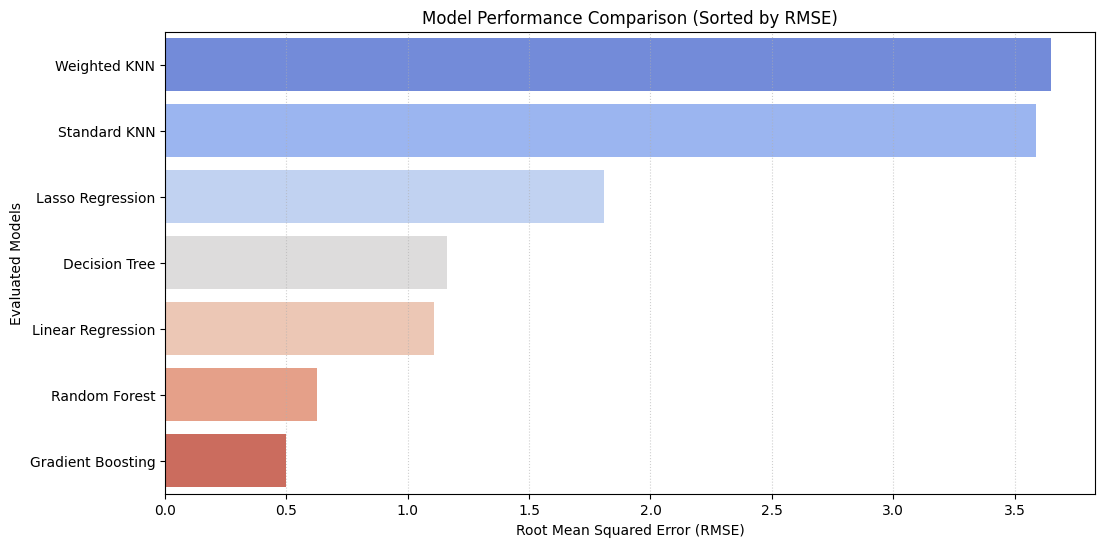

In [90]:
# Հորիզոնական սյունակավոր գրաֆիկի կառուցում՝ մոդելների էֆեկտիվությունը համեմատելու համար
plt.figure(figsize=(12, 6))

# Փոխելով x-ի և y-ի տեղերը՝ ստանում ենք հորիզոնական տեսք (օգտագործված է "coolwarm" գունային գամման)
sns.barplot(
    data=models_comparison_df.sort_values(by="RMSE_Score", ascending=False), # դասավորում ենք ըստ սխալանքի չափսի
    x="RMSE_Score",
    y="Regression_Model",
    palette="coolwarm"
)

# Առանցքների և գրաֆիկի ձևավորում
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Evaluated Models")
plt.title("Model Performance Comparison (Sorted by RMSE)")

# Օժանդակ ցանցի ավելացում միայն X առանցքի երկայնքով
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Գրաֆիկի ցուցադրում
plt.show()

/tmp/ipykernel_6465/236759893.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


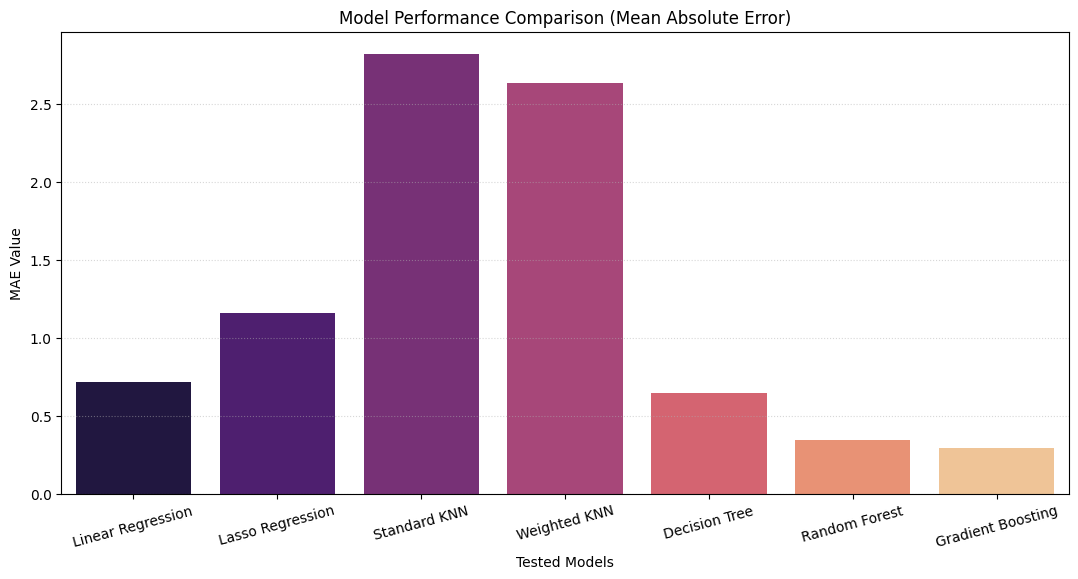

In [91]:
# Սյունակավոր գրաֆիկի (barplot) միջոցով ակնառու համեմատում ենք,
# թե որ մոդելն ունի ամենափոքր միջին բացարձակ սխալանքը (MAE)
plt.figure(figsize=(13, 6))

# Գրաֆիկի կառուցում նոր DataFrame-ի հիման վրա (y առանցքի համար ընտրված է "MAE_Score")
sns.barplot(
    data=models_comparison_df,
    x="Regression_Model",
    y="MAE_Score",
    palette="magma"
)

# Առանցքների և գրաֆիկի վերնագրերի տեղադրում
plt.xlabel("Tested Models")
plt.ylabel("MAE Value")
plt.title("Model Performance Comparison (Mean Absolute Error)")

# Իքս առանցքի անվանումների թեքում՝ ավելի հեշտ ընթեռնելիության համար
plt.xticks(rotation=15)

# Օժանդակ հորիզոնական ցանցի ակտիվացում
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Գրաֆիկի ցուցադրում
plt.show()